In [1]:
import logging
import pickle

import fiona
import folium
import geopandas as gpd
import pandas as pd
import seaborn as sns
from folium.plugins import HeatMap, HeatMapWithTime

import atlas.eugene as eug

In [2]:
import black
import jupyter_black

jupyter_black.load(
    # lab=False,
    line_length=78,
    # verbosity="DEBUG",
    target_version=black.TargetVersion.PY310,
)

# ODOT crashes for Eugene and selected cities



## Overview

The big question is: Why are fatalities going up? Visualizations suggest a few things:

1. Eugene is small enough, and its fatality rate low enough, that its fatality rate is subject to statistical noise year over year.
2. Whatever real increase is happening is following the same trend that state and national trends are.

This is not a hopeful result. It implies that as far as traffic fatalities, we may not have much local control over trends.

However, our overall crash, injury, and fatality rates remain lower than many other cities.
It is possible we are doing the right thing as far as absolute rates - but we may not be able to buck the trend in direction,
due to increased vehicle size and driver distractions.

## Methodology

Eugene, comparable cities in Oregon,
Oregon as a whole, and the US are compared for crashes, injuries, and fatalities.

Cities of similar size to Eugene that are suburbs of Portland are ignored, as
being a 'different kind of beast'.

Sources: 
* [ODOT Crash Statistics](https://www.oregon.gov/ODOT/Data/Pages/Crash.aspx)
* [Oregon GEOHub City Limits](https://geohub.oregon.gov/datasets/87ba24bbe79d47c3950d4e9d1ff0770c_220/explore)
* [NHTSA FARS Tables](https://www-fars.nhtsa.dot.gov/Main/index.aspx)
* [PSU Population Research Center](https://www.pdx.edu/population-research/)
* [FBI Crime Data Explorer](https://cde.ucr.cjis.gov/LATEST/webapp/#/pages/explorer/crime/crime-trend)

In [3]:
logger = logging.getLogger()

In [4]:
comparison_cities = [
    "Eugene",
    "Portland",
    "Salem",
    "Bend",
    "Medford",
    "Springfield",
    #    "Corvallis",
    #    "Albany",
]

In [5]:
def get_comparison_cities_gdf():
    cities = gpd.read_file(
        "data/state-of-oregon/oregon-city-limits.geojson"
    ).to_crs(crs="EPSG:2992")

    return cities[cities["CITYNAME"].isin(comparison_cities)]


comparison_cities_gdf = get_comparison_cities_gdf()

In [6]:
columns = [
    "ALCHL_INVLV_FLG",
    "CITY_SECT_NM",
    "CMPSS_DIR_SHORT_DESC",
    "CNTY_NM",
    "COLLIS_TYP_LONG_DESC",
    "CRASH_CAUSE_1_LONG_DESC",
    "CRASH_CAUSE_2_LONG_DESC",
    "CRASH_CAUSE_3_LONG_DESC",
    "CRASH_DT",
    "CRASH_EVNT_1_LONG_DESC",
    "CRASH_EVNT_2_LONG_DESC",
    "CRASH_EVNT_3_LONG_DESC",
    "CRASH_HIT_RUN_FLG",
    "CRASH_HR_NO",
    "CRASH_MO_NO",
    "CRASH_SPEED_INVLV_FLG",
    "CRASH_SVRTY_LONG_DESC",
    "CRASH_TYP_LONG_DESC",
    "CRASH_YR_NO",
    "DRUG_INVLV_FLG",
    "DRVWY_REL_FLG",
    "EFFECTV_DT",
    "FC_DESC",
    "FROM_ISECT_DSTNC_QTY",
    "HIGHEST_INJ_SVRTY_DESC",
    "HWY_COMPNT_LONG_DESC",
    "HWY_MED_NM",
    "HWY_NO",
    "HWY_SFX_NO",
    "INVSTG_AGY_LONG_DESC",
    "ISECT_ST_FULL_NM",
    "ISECT_TYP_SHORT_DESC",
    "LGT_COND_LONG_DESC",
    "LN_QTY",
    "MEDN_TYP_LONG_DESC",
    "MJ_INVLV_FLG",
    "OFF_RDWY_FLG",
    "POP_RNG_MED_DESC",
    "POST_SPEED_LMT_VAL",
    "RD_CHAR_LONG_DESC",
    "RD_CNTL_MED_DESC",
    "RD_SURF_MED_DESC",
    "RNDABT_FLG",
    "RTE_NM",
    "SCHL_ZONE_IND",
    "SPECL_JRSDCT_LONG_DESC",
    "ST_FULL_NM",
    "TOT_FATAL_CNT",
    "TOT_INJ_CNT",
    "TOT_INJ_LVL_A_CNT",
    "TOT_INJ_LVL_B_CNT",
    "TOT_INJ_LVL_C_CNT",
    "TOT_OCCUP_CNT",
    "TOT_PEDCYCL_CNT",
    "TOT_PEDCYCL_FATAL_CNT",
    "TOT_PEDCYCL_INJ_CNT",
    "TOT_PED_CNT",
    "TOT_PED_FATAL_CNT",
    "TOT_PED_INJ_CNT",
    "TOT_PER_INVLV_CNT",
    "TOT_SFTY_EQUIP_UNUSED_QTY",
    "TOT_SFTY_EQUIP_USED_QTY",
    "TOT_SFTY_EQUIP_USE_UNKNWN_QTY",
    "TOT_UNINJD_AGE00_04_CNT",
    "TOT_UNINJD_PER_CNT",
    "TOT_UNKNWN_CNT",
    "TOT_UNKNWN_FATAL_CNT",
    "TOT_UNKNWN_INJ_CNT",
    "TOT_VHCL_CNT",
    "TRAF_CNTL_DEVICE_LONG_DESC",
    "TRAF_CNTL_FUNC_FLG",
    "TURNG_LEG_QTY",
    "UNLOCT_FLG",
    "URB_AREA_LONG_NM",
    "WRK_ZONE_IND",
    "WTHR_COND_LONG_DESC",
]

In [7]:
display_columns = [
    "ALCHL_INVLV_FLG",
    "COLLIS_TYP_LONG_DESC",
    "CRASH_CAUSE_1_LONG_DESC",
    "CRASH_CAUSE_2_LONG_DESC",
    "CRASH_CAUSE_3_LONG_DESC",
    "CRASH_DT",
    "CRASH_YR_NO",
    "CRASH_EVNT_1_LONG_DESC",
    "CRASH_EVNT_2_LONG_DESC",
    "CRASH_EVNT_3_LONG_DESC",
    "CRASH_HIT_RUN_FLG",
    "CRASH_SVRTY_LONG_DESC",
    "CRASH_TYP_LONG_DESC",
    "EFFECTV_DT",
    "LGT_COND_LONG_DESC",
    "POST_SPEED_LMT_VAL",
    "TOT_FATAL_CNT",
    "TOT_INJ_CNT",
    "TOT_OCCUP_CNT",
    "TOT_PEDCYCL_CNT",
    "TOT_PEDCYCL_FATAL_CNT",
    "TOT_PEDCYCL_INJ_CNT",
    "TOT_PED_CNT",
    "TOT_PED_FATAL_CNT",
    "TOT_PED_INJ_CNT",
    "TOT_PER_INVLV_CNT",
    "TOT_VHCL_CNT",
    "WTHR_COND_LONG_DESC",
    "geometry",
]

In [8]:
population = pd.read_csv(
    "/home/nbirnel/eugene/atlas-of-eugene/data/own/from-psu-population/2010-2024-oregon-cities-population.csv"
)


def get_population(row):
    city = row["city"]
    year = str(row["CRASH_YR_NO"])
    return population[population["city"] == city][year].iloc[0]


OREGON_POPULATION = pd.read_csv(
    "data/own/from-psu-population/1960-2024-oregon-population.csv",
    dtype={"year": int, "population": int},
)

In [9]:
def get_city(row):
    def by_geometry():
        for city in comparison_cities_gdf.itertuples():
            if city.geometry.contains(row.geometry):
                return city.CITYNAME
        return "Unincorporated"

    section = row["CITY_SECT_NM"]
    if not isinstance(section, str):
        return by_geometry()
    if "Portland" in section:
        return "Portland"
    if section in comparison_cities:
        return section
    return by_geometry()

In [10]:
def get_city_preliminary(row):
    section = row["CITY_SECT_NM"]
    if "Portland" in section:
        return "Portland"
    return section

In [11]:
def get_crashes(name, mask=None):
    cache = f"cache/odot_crashes/{name}.pickle"
    try:
        return eug.get_pickle(cache)
    except Exception as e:
        print(e)
        pass
    crashes = {}
    for year in range(2014, 2024):
        file = f"data/state-of-oregon/odot/{year}_Statewide_Crashes.gdb.zip"
        layers = fiona.listlayers(file)
        layer_names = [
            f"crashes{year}",
            f"Crashes_{year}",
            "crashes",
        ]
        for layer in layer_names:
            if layer in layers:
                crashes[year] = gpd.read_file(
                    file,
                    layer=layer,
                    mask=mask,
                    columns=columns,
                )
                break
        for column in crashes[year].columns:
            if column.endswith("_FLG"):
                crashes[year][column] = crashes[year][column].astype(
                    "boolean"
                )
            elif column.endswith("_DESC"):
                crashes[year][column] = crashes[year][column].astype(
                    "category"
                )
            elif column.endswith("_NM"):
                crashes[year][column] = crashes[year][column].astype(
                    "category"
                )
            elif column.endswith("_IND"):
                crashes[year][column] = crashes[year][column].astype(
                    "category"
                )

    crashes = pd.concat(crashes.values())
    crashes["CRASH_YR_NO"] = crashes["CRASH_YR_NO"].astype(int)
    if name == "oregon":
        crashes["city"] = "OR-all"
        crashes = crashes.merge(
            OREGON_POPULATION,
            how="left",
            left_on="CRASH_YR_NO",
            right_on="year",
        )
        crashes = crashes.drop(columns=["year"])
    else:
        crashes["city"] = crashes.apply(get_city, axis=1)
        crashes["population"] = crashes.apply(get_population, axis=1)

    crashes["crashes"] = 1
    with open(cache, "wb") as f:
        pickle.dump(crashes, f, pickle.HIGHEST_PROTOCOL)
    return crashes

In [12]:
def get_last_year_crashes(name):
    cache = "cache/odot_crashes/last_year_crashes.pickle"
    try:
        return eug.get_pickle(cache)
    except:
        pass

    crashes = pd.read_excel(
        "data/state-of-oregon/odot/2024_preliminary_fatal_and_injury_crash_data.xls",
        header=2,
    )

    crashes = crashes.drop(crashes.tail(5).index)
    crashes.CRASH_YR_NO = crashes.CRASH_YR_NO.astype(int)
    crashes = crashes.rename(
        columns={
            "PEOPLE_KILLED": "TOT_FATAL_CNT",
            "PEOPLE_INJURED": "TOT_INJ_CNT",
            "TOTAL_CRASHES": "crashes",
        }
    )
    for column in ["TOT_FATAL_CNT", "TOT_INJ_CNT", "crashes"]:
        crashes[column] = crashes[column].astype(int)

    if name == "oregon":
        crashes["city"] = "OR-all"
        crashes = crashes.merge(
            OREGON_POPULATION,
            how="left",
            left_on="CRASH_YR_NO",
            right_on="year",
        )
        crashes = crashes.drop(columns=["year"])
    else:
        crashes["city"] = crashes.apply(get_city_preliminary, axis=1)
        crashes = crashes[crashes.city.isin(comparison_cities)]

        crashes["population"] = crashes.apply(get_population, axis=1)

    with open(cache, "wb") as f:
        pickle.dump(crashes, f, pickle.HIGHEST_PROTOCOL)
    return crashes

In [13]:
old_crashes = get_crashes("comparison_cities", comparison_cities_gdf)
last_year = get_last_year_crashes("comparison_cities")
all_crashes = pd.concat([old_crashes, last_year])

In [14]:
old_crashes[
    (old_crashes.city == "Eugene") & (old_crashes["TOT_FATAL_CNT"] > 0)
]["TOT_FATAL_CNT"].sum()

np.int64(72)

In [15]:
all_crashes = all_crashes.to_crs(4326)
all_crashes["lng"] = all_crashes["geometry"].x
all_crashes["lat"] = all_crashes["geometry"].y

In [16]:
eugene = all_crashes[all_crashes["city"] == "Eugene"]

In [17]:
eugene[eugene["CRASH_YR_NO"] > 2021][
    ["TOT_INJ_LVL_A_CNT", "TOT_FATAL_CNT"]
].sum()

TOT_INJ_LVL_A_CNT    200.0
TOT_FATAL_CNT         40.0
dtype: float64

In [18]:
eugene_ped_and_cycle_crashes = all_crashes[
    (all_crashes["city"] == "Eugene")
    & (
        (all_crashes["TOT_PEDCYCL_CNT"] > 0)
        | (all_crashes["TOT_PED_CNT"] > 0)
    )
]

In [19]:
city_of_eugene = gpd.read_file(
    "data/city-of-eugene/Eugene_City_Limits_-_HUB.geojson"
)

In [20]:
complete_aggregator = {
    "TOT_FATAL_CNT": "sum",
    "TOT_INJ_CNT": "sum",
    "TOT_INJ_LVL_A_CNT": "sum",
    "TOT_INJ_LVL_B_CNT": "sum",
    "TOT_INJ_LVL_C_CNT": "sum",
    "TOT_PEDCYCL_FATAL_CNT": "sum",
    "TOT_PED_FATAL_CNT": "sum",
    "TOT_PEDCYCL_INJ_CNT": "sum",
    "TOT_PED_INJ_CNT": "sum",
    "crashes": "sum",
    "population": "first",
}

preliminary_aggregator = {
    "TOT_FATAL_CNT": "sum",
    "TOT_INJ_CNT": "sum",
    "crashes": "sum",
    "population": "first",
}

In [21]:
def get_aggregate(df, aggregator: dict):
    agg = (
        df[
            [
                "CRASH_YR_NO",
                "city",
            ]
            + list(aggregator.keys())
        ]
        .groupby(["CRASH_YR_NO", "city"])
        .aggregate(aggregator)
    )
    for k, v in aggregator.items():
        if v == "sum":
            column = f"{k.replace('TOT_', '').replace('_CNT', '').lower()}_per_100K"
            agg[column] = agg[k] * (10**5 / agg["population"])

    agg["fatalities_per_100K"] = agg["TOT_FATAL_CNT"] * (
        10**5 / agg["population"]
    )
    agg["injuries_per_100K"] = agg["TOT_INJ_CNT"] * (
        10**5 / agg["population"]
    )
    agg["crashes_per_100K"] = agg["crashes"] * (10**5 / agg["population"])

    return agg

In [22]:
def get_all_aggregated():
    cache = "cache/odot_crashes/aggregated_crashes.pickle"
    try:
        return eug.get_pickle(cache)
    except:
        pass
    df = pd.concat(
        [
            get_aggregate(
                pd.concat(
                    [
                        get_crashes(
                            "comparison_cities",
                            mask=comparison_cities_gdf,
                        ),
                        get_crashes("oregon"),
                    ]
                ),
                complete_aggregator,
            ),
            get_aggregate(
                pd.concat(
                    [
                        get_last_year_crashes("comparison_cities"),
                        get_last_year_crashes("oregon"),
                    ]
                ),
                preliminary_aggregator,
            ),
        ]
    )

    fars = pd.read_csv("data/nhtsa/fars-summary.csv")
    fars_range = range(2014, 2024)
    fars_fatality_rate = fars[
        fars["colname"] == "Fatalities per 100000 Population"
    ][[str(i) for i in fars_range]]

    for i in fars_range:
        df.loc[(i, "US-all"), "fatalities_per_100K"] = float(
            fars_fatality_rate[str(i)].iloc[0]
        )
    df = df.sort_values(by="CRASH_YR_NO")

    with open(cache, "wb") as f:
        pickle.dump(df, f, pickle.HIGHEST_PROTOCOL)
    return df

In [23]:
fars = pd.read_csv("data/nhtsa/fars-summary.csv")
fars = fars.set_index("colname")

In [24]:
def display(df, metric: str, end_year=2025, title=None):

    if title is None:
        title = metric.title()

    by_city = df[[f"{metric}_per_100K"]].unstack().fillna(0)
    cities = list(by_city.columns.get_level_values(1))

    by_city.columns = cities

    cities.remove("Eugene")
    cities.remove("OR-all")
    try:
        cities.remove("US-all")
        cities.append("US-all")
    except:
        pass
    cities.insert(0, "OR-all")
    cities.insert(0, "Eugene")

    by_city.index = list(range(2014, end_year))

    sns.set_theme(palette="pastel")
    sns.set_style("white")

    ax = sns.lineplot(data=by_city[cities])

    ax.set_title(f"Traffic {title} per 100K Residents")
    ax.set(xlabel="Year")
    sns.move_legend(ax, "upper right", bbox_to_anchor=(1.5, 1))

In [25]:
comparison = get_all_aggregated()

In [26]:
exclude_last_year = comparison.drop(
    comparison.index.get_level_values(0)[-1], level=0
)
exclude_last_year = exclude_last_year.drop("US-all", level=1)

## Crashes

Non-fatality crash data is suspect on a national level due to varying reporting policies,
so US-all is not included.

Reported crashes show a similar pattern across the various cities, and Oregon as a whole.
Crashes seem to be declining from 2016 to 2019, drop precipitously in 2020,
then rise again over the next few years, but mostly not to pre-pandemic levels.

Eugene's numbers are low compared to other cities and to Oregon.
(Albany and Corvallis are lower still, but we run out of visually distinguishable colors.)
It is impossible to know if this is due to reporting rate or better safety,
but the shape over time follows that of other cities.


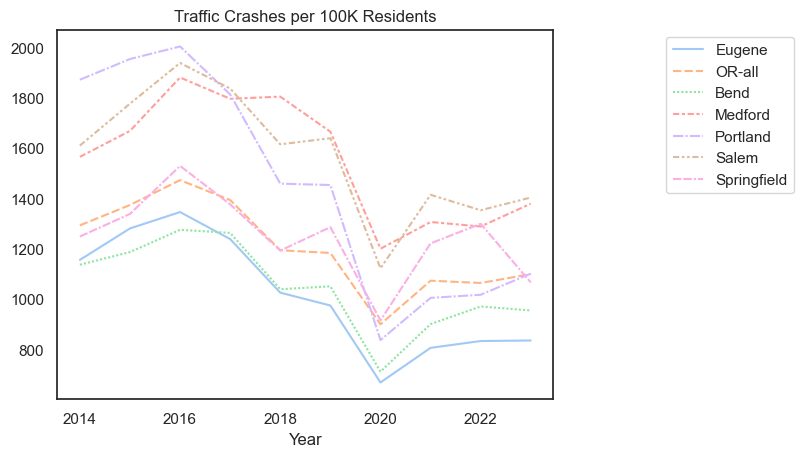

In [27]:
display(exclude_last_year, "crashes", 2024)

## Injuries

We skip US-all for injuries for similar reasons to crashes.

Overall reported injuries look very similar to reported crashes,
with the same decline, steep drop in 2020, and partial rebound in years since.

However, when broken down by severity the picture is very different.
The worst injuries, Level A and B, have skyrocketed in all jurisdictions since 2021, 
far beyond pre-pandemic levels. 
Level C injuries have tapered off in the same time period. 
This is a difficult to interpret result.



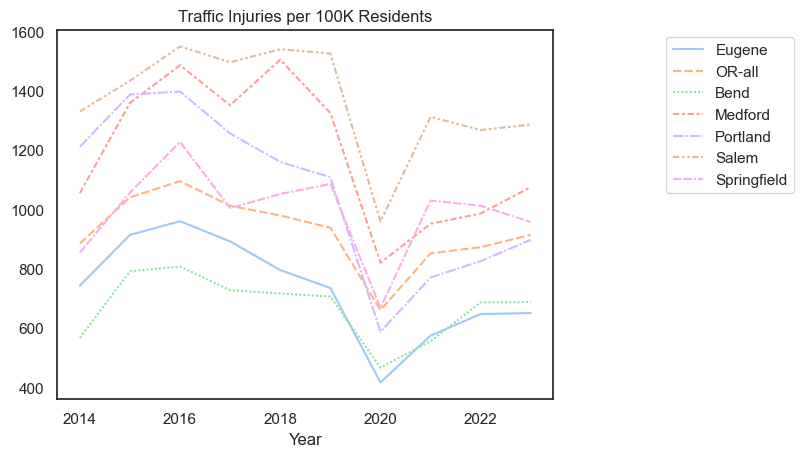

In [28]:
display(exclude_last_year, "injuries", 2024)

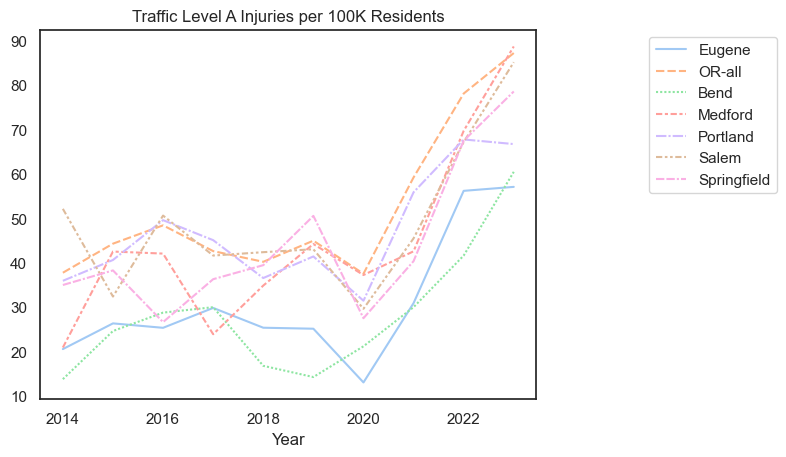

In [29]:
display(exclude_last_year, "inj_lvl_a", 2024, "Level A Injuries")

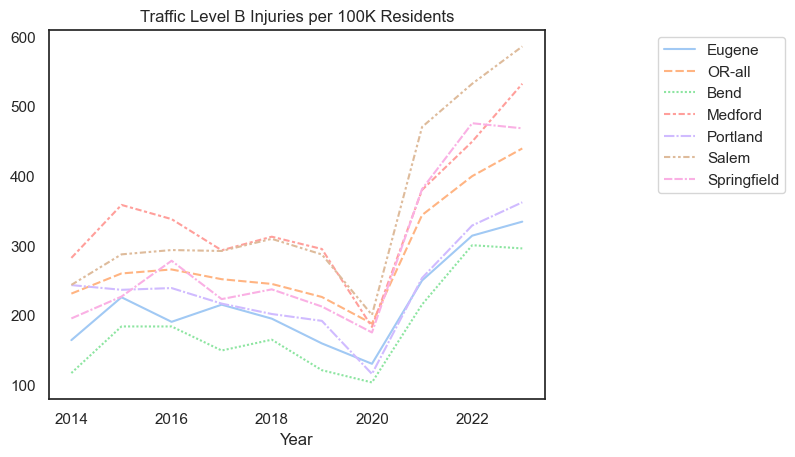

In [30]:
display(exclude_last_year, "inj_lvl_b", 2024, "Level B Injuries")

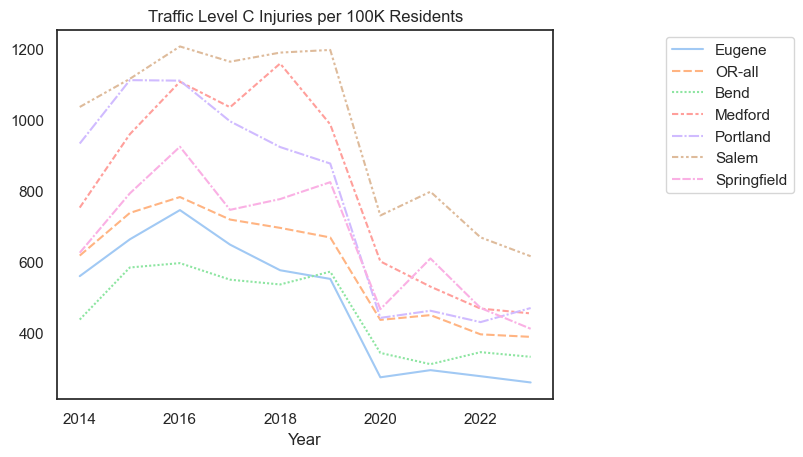

In [31]:
display(exclude_last_year, "inj_lvl_c", 2024, "Level C Injuries")

# Traffic Fatalities

Traffic Fatalities are likely to be more consistently reported than non-fatal crashes,
so we include US federal data for this plot.

Since traffic fatalities occur in small numbers locally,
the numbers are more subject to statistical noise when measured in smaller cities.
This is reflected in the plot, which shows big spikes and dips yearly for cities smaller than Portland,
but not so much for Portland, Oregon, and the US.

We also include 2024 data in the plot, although it is preliminary.
This means that Oregon and the US show large dropoffs in 2024,
which should not be trusted.

Eugene's numbers show a similar shape to Oregon and the US: flat until
2020, followed by a multi-year spike.

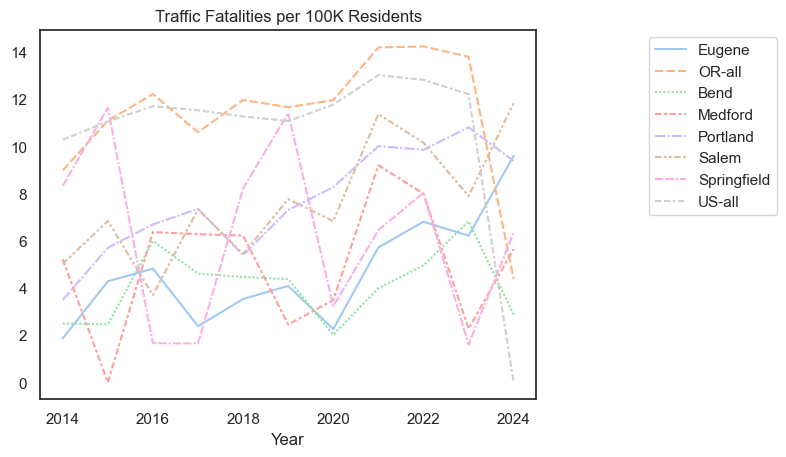

In [32]:
display(comparison, "fatalities")

In [33]:
murders = pd.read_csv(
    "data/fbi/2014-2024-eugene-police-department-homicide.csv"
)
murders = murders.transpose().rename(columns={0: "Homicides"})
murders.index = murders.index.rename("Year").astype(int)

traffic_fatalities = (
    all_crashes[all_crashes["city"] == "Eugene"]
    .rename(
        columns={"CRASH_YR_NO": "Year", "TOT_FATAL_CNT": "Traffic Fatalities"}
    )[["Year", "Traffic Fatalities"]]
    .groupby("Year")
    .sum()
)

## Traffic Fatalities and Homicides

Finally, we compare traffic fatalities to homicides, just in Eugene. 
We see that cars violence is the more frequent cause of violent death than homicide in every single year since at least 2014.

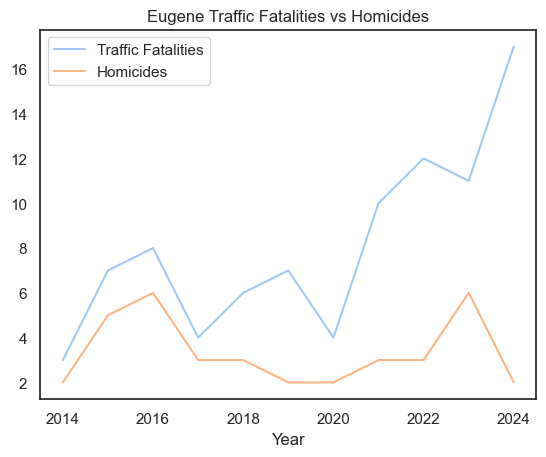

In [34]:
ax = traffic_fatalities.join(murders).plot.line(
    title="Eugene Traffic Fatalities vs Homicides"
)